In [1]:
!pip install evaluate jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 60.3 MB/s eta 0:00:00:00:01


## Лабораторна робота №1
##### Виконали студенти групи КІ-51мп:
Архипов Яків <br>
Польнікова Поліна <br>
Ткаченко Марія <br>

In [45]:
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import IPython.display as ipd
from transformers import HubertModel
from transformers import AutoConfig
from collections import Counter
from torch.utils.data import Dataset
import torch
from transformers import Wav2Vec2FeatureExtractor
import torch.nn as nn
from transformers import HubertModel
import evaluate
from transformers import TrainingArguments, Trainer
from sklearn.metrics import confusion_matrix
from transformers import Wav2Vec2Model

# Завдання 1

# Dataset

In [3]:
BASE_PATH = '/kaggle/input/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech'
DATA_DIR = os.path.join(BASE_PATH, 'data')

In [4]:
train_df = pd.read_csv(os.path.join(BASE_PATH, 'train_data.csv'))
print(f"Загальна кількість записів у train_data.csv: {len(train_df)}")
display(train_df.head())

Загальна кількість записів у train_data.csv: 31678


,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
0,1.0,TRAIN,DR4,MMDM0,SI681.WAV.wav,TRAIN/DR4/MMDM0/SI681.WAV.wav,TRAIN\\DR4\\MMDM0\\SI681.WAV.wav,True,True,False,False,False
1,2.0,TRAIN,DR4,MMDM0,SI1311.PHN,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN,False,False,False,True,False
2,3.0,TRAIN,DR4,MMDM0,SI1311.WRD,TRAIN/DR4/MMDM0/SI1311.WRD,TRAIN\\DR4\\MMDM0\\SI1311.WRD,False,False,True,False,False
3,4.0,TRAIN,DR4,MMDM0,SX321.PHN,TRAIN/DR4/MMDM0/SX321.PHN,TRAIN\\DR4\\MMDM0\\SX321.PHN,False,False,False,True,False
4,5.0,TRAIN,DR4,MMDM0,SX321.WRD,TRAIN/DR4/MMDM0/SX321.WRD,TRAIN\\DR4\\MMDM0\\SX321.WRD,False,False,True,False,False


In [5]:
train_df = pd.read_csv(os.path.join(BASE_PATH, 'train_data.csv'))

train_df['ext'] = train_df['filename'].str.split('.').str[-1].str.upper()
print(f"{'Колонка':<20} | {'Унікальних':<10}")
print("-" * 60)

for col in train_df.columns:
    unique_count = train_df[col].nunique()
    print(f"{col:<20} | {unique_count:<10}")

print("\nДетальна статистика форматів")
print(train_df['ext'].value_counts())

Колонка              | Унікальних
------------------------------------------------------------
index                | 23100     
test_or_train        | 1         
dialect_region       | 8         
speaker_id           | 462       
filename             | 8590      
path_from_data_dir   | 23100     
path_from_data_dir_windows | 23100     
is_converted_audio   | 2         
is_audio             | 2         
is_word_file         | 2         
is_phonetic_file     | 2         
is_sentence_file     | 2         
ext                  | 4         

Детальна статистика форматів
ext
WAV    9240
PHN    4620
WRD    4620
TXT    4620
Name: count, dtype: int64


### Формування пар даних (Audio-PHN)

У датасеті TIMIT звук і фонетична розмітка лежать у різних файлах, тому їх потрібно синхронізувати, щоб модель бачила звук і правильну відповідь одночасно. 

Код автоматично зіставляє аудіо та мітки за унікальним ключем (диктор + ID речення), що гарантує відсутність помилок у навчальній вибірці.

Моделі HuBERT потрібна чітка структура: «масив байтів відповідає чіткій послідовності фонем.

In [6]:
def prepare_timit_subset(current_df):
    """
    Підготовлює таблицю пар (Аудіо + PHN) для конкретної вибірки.
    "TRAIN" або "TEST"
    """
    audio_sub = current_df[current_df['is_converted_audio'] == True].copy()
    # Створюємо чистий ID файлу (напр. SI681.WAV.wav -> SI681) 
    audio_sub['file_id'] = audio_sub['filename'].str.split('.').str[0]
    audio_sub = audio_sub[['path_from_data_dir', 'path_from_data_dir_windows', 'dialect_region', 'speaker_id', 'file_id']]
    audio_sub = audio_sub.rename(columns={
        'path_from_data_dir': 'path_from_data_dir_wav',
        'path_from_data_dir_windows': 'path_from_data_dir_windows_wav'
    })
    phn_sub = current_df[current_df['is_phonetic_file'] == True].copy()
    # Створюємо чистий ID файлу (напр. SI681.PHN -> SI681) 
    phn_sub['file_id'] = phn_sub['filename'].str.split('.').str[0]
    phn_sub = phn_sub[['path_from_data_dir', 'path_from_data_dir_windows', 'dialect_region', 'speaker_id', 'file_id']]
    phn_sub = phn_sub.rename(columns={
        'path_from_data_dir': 'path_from_data_dir_phn',
        'path_from_data_dir_windows': 'path_from_data_dir_windows_phn'
    })
    merged_df = pd.merge(
        audio_sub, 
        phn_sub, 
        on=['speaker_id', 'file_id', 'dialect_region']
    )
    print(f"Знайдено повних пар (Audio+PHN): {len(merged_df)}")
    return merged_df

train_dataset = prepare_timit_subset(train_df)
train_dataset

Знайдено повних пар (Audio+PHN): 1680


,path_from_data_dir_wav,path_from_data_dir_windows_wav,dialect_region,speaker_id,file_id,path_from_data_dir_phn,path_from_data_dir_windows_phn
0,TRAIN/DR4/MMDM0/SI681.WAV.wav,TRAIN\\DR4\\MMDM0\\SI681.WAV.wav,DR4,MMDM0,SI681,TRAIN/DR4/MMDM0/SI681.PHN,TRAIN\\DR4\\MMDM0\\SI681.PHN
1,TRAIN/DR4/MMDM0/SI1311.WAV.wav,TRAIN\\DR4\\MMDM0\\SI1311.WAV.wav,DR4,MMDM0,SI1311,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN
2,TRAIN/DR4/MMDM0/SX141.WAV.wav,TRAIN\\DR4\\MMDM0\\SX141.WAV.wav,DR4,MMDM0,SX141,TRAIN/DR4/MMDM0/SX141.PHN,TRAIN\\DR4\\MMDM0\\SX141.PHN
3,TRAIN/DR4/MMDM0/SX51.WAV.wav,TRAIN\\DR4\\MMDM0\\SX51.WAV.wav,DR4,MMDM0,SX51,TRAIN/DR4/MMDM0/SX51.PHN,TRAIN\\DR4\\MMDM0\\SX51.PHN
4,TRAIN/DR4/MMDM0/SX411.WAV.wav,TRAIN\\DR4\\MMDM0\\SX411.WAV.wav,DR4,MMDM0,SX411,TRAIN/DR4/MMDM0/SX411.PHN,TRAIN\\DR4\\MMDM0\\SX411.PHN
...,...,...,...,...,...,...,...
1675,TRAIN/DR2/MMAA0/SA1.WAV.wav,TRAIN\\DR2\\MMAA0\\SA1.WAV.wav,DR2,MMAA0,SA1,TRAIN/DR2/MMAA0/SA1.PHN,TRAIN\\DR2\\MMAA0\\SA1.PHN
1676,TRAIN/DR2/MMAA0/SX305.WAV.wav,TRAIN\\DR2\\MMAA0\\SX305.WAV.wav,DR2,MMAA0,SX305,TRAIN/DR2/MMAA0/SX305.PHN,TRAIN\\DR2\\MMAA0\\SX305.PHN
1677,TRAIN/DR2/MMAA0/SA2.WAV.wav,TRAIN\\DR2\\MMAA0\\SA2.WAV.wav,DR2,MMAA0,SA2,TRAIN/DR2/MMAA0/SA2.PHN,TRAIN\\DR2\\MMAA0\\SA2.PHN
1678,TRAIN/DR2/MMAA0/SX125.WAV.wav,TRAIN\\DR2\\MMAA0\\SX125.WAV.wav,DR2,MMAA0,SX125,TRAIN/DR2/MMAA0/SX125.PHN,TRAIN\\DR2\\MMAA0\\SX125.PHN


### Часове вирівнювання фонем (Frame-level Alignment)


Оскільки модель бачить звук не безперервно, а окремими вікнами по 20 мс (320 відліків), нам потрібно розтягнути кожну фонему на відповідну кількість кадрів.

conv_stride": [
    5,
    2,
    2,
    2,
    2,
    2,
    2
  ] = 5 * 2 * 2 * 2 * 2 * 2 * 2 = 320

Перетворити фонетичну розмітку з одиниць «відліки» у «кадри моделі». Ми «розтягуємо» кожну фонему пропорційно до її тривалості, щоб на кожен вихідний вектор моделі припадала рівно одна правильна мітка. Це дозволяє уникнути помилок несумісності розмірів (size mismatch) під час обчислення Loss-функції.

In [7]:
config = AutoConfig.from_pretrained("facebook/hubert-base-ls960")
config

config.json: 0.00B [00:00, ?B/s]

HubertConfig {
  "activation_dropout": 0.1,
  "apply_spec_augment": true,
  "architectures": [
    "HubertModel"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": 1,
  "classifier_proj_size": 256,
  "conv_bias": false,
  "conv_dim": [
    512,
    512,
    512,
    512,
    512,
    512,
    512
  ],
  "conv_kernel": [
    10,
    3,
    3,
    3,
    3,
    2,
    2
  ],
  "conv_pos_batch_norm": false,
  "conv_stride": [
    5,
    2,
    2,
    2,
    2,
    2,
    2
  ],
  "ctc_loss_reduction": "sum",
  "ctc_zero_infinity": false,
  "do_stable_layer_norm": false,
  "eos_token_id": 2,
  "feat_extract_activation": "gelu",
  "feat_extract_dropout": 0.0,
  "feat_extract_norm": "group",
  "feat_proj_dropout": 0.1,
  "feat_proj_layer_norm": true,
  "final_dropout": 0.1,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout": 0.1,
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-05,


In [8]:
FRAME_STRIDE = 320

def get_frame_labels(phn_path, stride=FRAME_STRIDE):
    """
    Перетворює відліки з PHN файлу в послідовність міток для кожного кадру.
    """ 
    actual_path = os.path.join(DATA_DIR, phn_path).replace('\\', '/') 
    frames = []
    try:
        with open(actual_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 3:
                    start, end, label = parts
                    start_frame = int(start) // stride
                    end_frame = int(end) // stride
                    duration = end_frame - start_frame # скільки звук займає кадрів
                    frames.extend([label] * duration)
        return frames
    except Exception:
        return []

train_dataset['frame_labels'] = train_dataset['path_from_data_dir_phn'].apply(get_frame_labels)
empty_rows = (train_dataset['frame_labels'].str.len() == 0).sum()
print(f"Файлів, які не вдалося обробити: {empty_rows}")
if empty_rows < len(train_dataset):
    print("Приклад перших 10 кадрів:", train_dataset[train_dataset['frame_labels'].str.len() > 0]['frame_labels'].iloc[0][:10])

Файлів, які не вдалося обробити: 0
Приклад перших 10 кадрів: ['h#', 'h#', 'h#', 'h#', 'h#', 'h#', 'w', 'ix', 'ix', 'ix']


### Реалізація класу Dataset для PyTorch

створюється об'єкт, який об’єднує наші табличні дані з логікою завантаження файлів. Клас TIMITDataset (який ми успадковуємо від стандартного torch.utils.data.Dataset) виконує три критичні функції:
* Динамічне завантаження: читає аудіофайл з диска лише тоді, коли він потрібен (це економить оперативну пам'ять).
* Ресемплінг: гарантує, що всі аудіо мають частоту 16 кГц.
* Числове кодування: перетворює «людські» назви фонем у числові індекси, які нейромережа HuBERT використовує для розрахунку помилки (Loss).

Знайдено унікальних фонем: 61
Список фонем: ['aa', 'ae', 'ah', 'ao', 'aw', 'ax', 'ax-h', 'axr', 'ay', 'b', 'bcl', 'ch', 'd', 'dcl', 'dh', 'dx', 'eh', 'el', 'em', 'en', 'eng', 'epi', 'er', 'ey', 'f', 'g', 'gcl', 'h#', 'hh', 'hv', 'ih', 'ix', 'iy', 'jh', 'k', 'kcl', 'l', 'm', 'n', 'ng', 'nx', 'ow', 'oy', 'p', 'pau', 'pcl', 'q', 'r', 's', 'sh', 't', 'tcl', 'th', 'uh', 'uw', 'ux', 'v', 'w', 'y', 'z', 'zh']


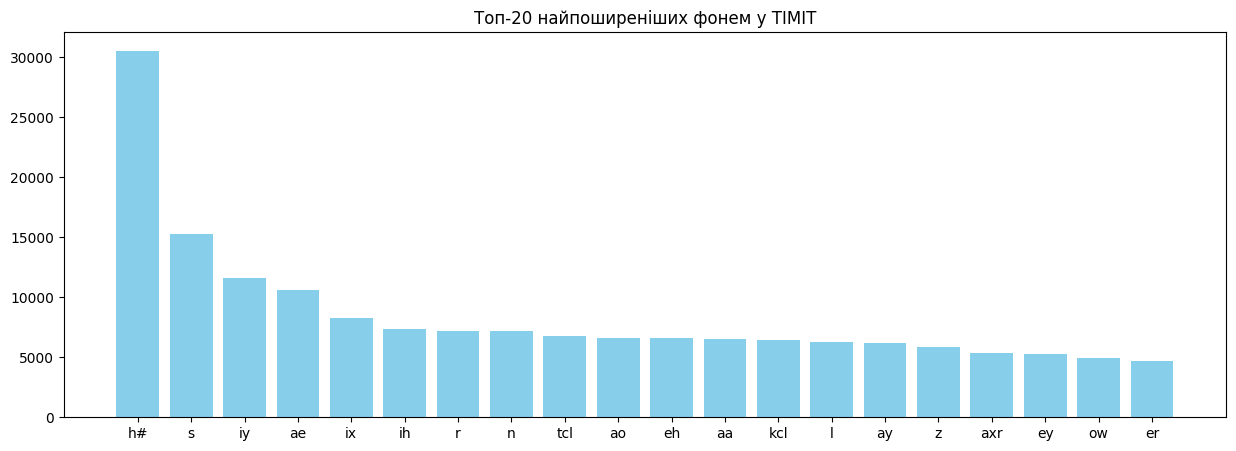

{'aa': 0,
 'ae': 1,
 'ah': 2,
 'ao': 3,
 'aw': 4,
 'ax': 5,
 'ax-h': 6,
 'axr': 7,
 'ay': 8,
 'b': 9,
 'bcl': 10,
 'ch': 11,
 'd': 12,
 'dcl': 13,
 'dh': 14,
 'dx': 15,
 'eh': 16,
 'el': 17,
 'em': 18,
 'en': 19,
 'eng': 20,
 'epi': 21,
 'er': 22,
 'ey': 23,
 'f': 24,
 'g': 25,
 'gcl': 26,
 'h#': 27,
 'hh': 28,
 'hv': 29,
 'ih': 30,
 'ix': 31,
 'iy': 32,
 'jh': 33,
 'k': 34,
 'kcl': 35,
 'l': 36,
 'm': 37,
 'n': 38,
 'ng': 39,
 'nx': 40,
 'ow': 41,
 'oy': 42,
 'p': 43,
 'pau': 44,
 'pcl': 45,
 'q': 46,
 'r': 47,
 's': 48,
 'sh': 49,
 't': 50,
 'tcl': 51,
 'th': 52,
 'uh': 53,
 'uw': 54,
 'ux': 55,
 'v': 56,
 'w': 57,
 'y': 58,
 'z': 59,
 'zh': 60}

In [37]:
all_labels = [item for sublist in train_dataset['frame_labels'] for item in sublist]
phoneme_counts = Counter(all_labels)
unique_phonemes = sorted(list(set(all_labels)))
phoneme_to_id = {p: i for i, p in enumerate(unique_phonemes)}

print(f"Знайдено унікальних фонем: {len(unique_phonemes)}")
print("Список фонем:", unique_phonemes)

top_20 = phoneme_counts.most_common(20)
labels, values = zip(*top_20)

plt.figure(figsize=(15, 5))
plt.bar(labels, values, color='skyblue')
plt.title("Топ-20 найпоширеніших фонем у TIMIT")
plt.show()

phoneme_to_id

Створили «карту відповідності» (phoneme_to_id), де кожна фонема отримала свій унікальний числовий номер. Це дозволяє перетворити списки звуків у тензори.

In [10]:
class TIMITDataset(Dataset):
    def __init__(self, df, phoneme_to_id, base_path):
        self.df = df
        self.phoneme_to_id = phoneme_to_id
        self.base_path = base_path

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Завантажуємо звук
        path_wav = os.path.join(self.base_path, self.df.iloc[idx]['path_from_data_dir_wav'])
        audio, _ = librosa.load(path_wav, sr=16000)
        # Отримуємо текстові фонеми (ті, що ми вже розбили по 320)
        text_phonemes = self.df.iloc[idx]['frame_labels']
        # Конвертуємо назви у числа через словник
        label_ids = [self.phoneme_to_id[p] for p in text_phonemes]
        return {
            "input_values": audio,
            "labels": label_ids
        }

dataset = TIMITDataset(train_dataset, phoneme_to_id, DATA_DIR)
sample = dataset[0]
print(f"--- Результати перевірки ---")
print(f"Тип даних аудіо: {type(sample['input_values'])} (numpy array)")
print(f"Розмірність аудіо (samples): {sample['input_values'].shape}")
print(f"Кількість міток (labels): {len(sample['labels'])}")
ratio = len(sample['input_values']) / len(sample['labels'])
print(f"Співвідношення Audio/Labels: {ratio:.2f} (Очікується ~320)")
print(f"\nПерші 5 міток (ID): {sample['labels'][:5]}")

--- Результати перевірки ---
Тип даних аудіо: <class 'numpy.ndarray'> (numpy array)
Розмірність аудіо (samples): (39936,)
Кількість міток (labels): 124
Співвідношення Audio/Labels: 322.06 (Очікується ~320)

Перші 5 міток (ID): [27, 27, 27, 27, 27]


### Динамічний падінг та маска

* Речення в TIMIT мають різну тривалість. DataCollator знаходить найдовше речення в батчі й дописує іншим нулі (падінг), щоб сформувати рівний прямокутний тензор.
* Автоматично створюється маска (0 та 1), яка вказує HuBERT, де закінчується реальний звук і починається порожнеча, щоб модель не витрачала ресурси на обробку нулів.
* Мітки (labels) для падінгу заповнюються числом -100. Це спеціальний індекс для PyTorch, де модель не нараховувує штраф і змінює ваги моделі на основі цього кадру.

In [11]:
class DataCollator:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, features):
        # features - це список словників від Dataset: [{"input_values": audio, "labels": [ids]}, ...]
        # Витягуємо аудіо та робимо падінг + маску
        input_features = [{"input_values": f["input_values"]} for f in features]
        batch = self.processor.pad(
            input_features, 
            padding=True,
            return_attention_mask=True, # створює тензор маски для трансформера
            return_tensors="pt"
        )
        # Витягуємо мітки та робимо падінг значенням -100
        label_sequences = [torch.tensor(f["labels"]) for f in features]
        labels_batch = torch.nn.utils.rnn.pad_sequence(
            label_sequences, 
            batch_first=True, 
            padding_value=-100
        )
        
        batch["labels"] = labels_batch
        return batch

from transformers import Wav2Vec2FeatureExtractor
# Використовуємо стандартний екстрактор для HuBERT
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960")
collator = DataCollator(feature_extractor)

mock_batch = [dataset[0], dataset[1]]
final_batch = collator(mock_batch)

print("--- Результати тестування батча ---")
print(f"Розмірність input_values (Audio): {final_batch['input_values'].shape}")
print(f"Розмірність attention_mask:      {final_batch['attention_mask'].shape}")
print(f"Розмірність labels (Мітки):      {final_batch['labels'].shape}")

# Перевірка падінгу в мітках
last_labels = final_batch['labels'][0][-5:] # останніх 5 міток першого прикладу
print(f"\nОстанні 5 міток першого прикладу: {last_labels.tolist()}")

preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

--- Результати тестування батча ---
Розмірність input_values (Audio): torch.Size([2, 86631])
Розмірність attention_mask:      torch.Size([2, 86631])
Розмірність labels (Мітки):      torch.Size([2, 270])

Останні 5 міток першого прикладу: [-100, -100, -100, -100, -100]


# Застосування моделей

a. Спробуйте кілька SSL-моделей — можна використати моделі з лекції та/або дослідити HF Model Hub і/або переглянути SUPERB Leaderboard.

## HubertModel

In [12]:
model_test_hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960")
print(model_test_hubert.feature_extractor)

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HubertFeatureEncoder(
  (conv_layers): ModuleList(
    (0): HubertGroupNormConvLayer(
      (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
      (activation): GELUActivation()
      (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
    )
    (1-4): 4 x HubertNoLayerNormConvLayer(
      (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
      (activation): GELUActivation()
    )
    (5-6): 2 x HubertNoLayerNormConvLayer(
      (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
      (activation): GELUActivation()
    )
  )
)


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

In [105]:
class HubertForPhonemeClassification(nn.Module):
    def __init__(self, num_labels, layer_index=12):
        super().__init__()
        self.num_labels = num_labels
        self.layer_index = layer_index 
        self.hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960")
        self.hubert.feature_extractor._freeze_parameters()
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.hubert.config.hidden_size, num_labels)

    def forward(self, input_values, attention_mask=None, labels=None):
        outputs = self.hubert(
            input_values, 
            attention_mask=attention_mask, 
            output_hidden_states=True
        )
        
        hidden_states = outputs.hidden_states[self.layer_index]
        x = self.dropout(hidden_states)
        logits = self.classifier(x)
        
        loss = None
        if labels is not None:
            # Вирівнюємо довжину, якщо є розбіжність в 1-2 кадри
            if logits.shape[1] != labels.shape[1]:
                min_len = min(logits.shape[1], labels.shape[1])
                logits = logits[:, :min_len, :]
                labels = labels[:, :min_len]

            loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            
            # використовуємо .reshape() замість .view()
            # Це дозволяє працювати з "неконтигуальними" тензорами після зрізів
            loss = loss_fct(logits.reshape(-1, self.num_labels), labels.reshape(-1))
            
        return {"loss": loss, "logits": logits}

Які були проблеми:

1. Проблема розмірності (ValueError)

Ми помітили, що HuBERT видає, наприклад, 776 кадрів, а в розмітці їх 780. Щоб програма не "впала", було додано підрізання.

*Детальніше про реалізацію*

Спочатку ми знайдемо чи у моделі менший вектор чи у розмітки, а потім дивимося скільки треба обрізати, щоб вони обидва мали спільну довжину.

Наприклад, при першому запуску була помилка, що розмітка давала 780 кадрів. Останні 4 кадри — це зазвичай тиша після слова або затухання останнього звуку. А модель 776 кадрів. Вона закінчила обробку трохи раніше через особливості своїх «вікон» (CNN filters). Тож, втрата 4 кадрів це 20*4=80 мс. 80 мілісекунд — це менше, ніж кліпнути оком. В кінці аудіофайлу це майже завжди або фоновий шум, або пауза. Втрата такої кількості інформації ніяк не впливає на загальний PER, але дозволяє математиці CrossEntropyLoss працювати коректно.

*Причина:*

Через те, що у HuBERT цілий каскад із 7 згорткових шарів (CNN). Хоча ми кажемо, що крок (stride) дорівнює 320, насправді кожен шар має свої власні параметри: розмір ядра (kernel size) та відступи (padding). Тож, маленькі «заокруглення» на кожному етапі накопичуються. В результаті модель може видати на 1-2 кадри менше, ніж ми очікували від простого ділення довжини аудіо на 320.

У коді робили «чисте» ділення: start_frame = int(start) // 320. Це лінійна логіка. Але HuBERT — це не лінійна лінійка. Його вхідні шари мають невелике перекриття (overlap). Тобто один і той самий шматочок звуку може частково потрапляти у два сусідні кадри. Через це «фізичні» межі звуку в розмітці TIMIT (.PHN) не завжди ідеально збігаються з «математичними» межами кадрів, які згенерував трансформер.

Тобто, якщо файл має 32,000 відліків: 32000/320=100.0 (ідеально). Якщо файл має 32,150 відліків: 32150/320=100.46. Модель HuBERT округлить це до 100, а логіка в цій лабораторній роботі або інший інструмент обробки може округлити до 101. Ось і з'явилася різниця.
   
2. Конфлікт з .view() (RuntimeError)

Метод .view(-1, self.num_labels) — дуже швидкий і ефективний, але він має одну жорстку вимогу: дані в пам'яті повинні лежати ідеально підряд, без дірок. Коли він бачить наш "підрізаний" тензор, він видає помилку: RuntimeError: view size is not compatible with input tensor's size and stride...
Це займає на мікросекунду більше часу, але це надійно.

*Детальніше про реалізацію*

Для усунення помилки метод .view() було замінено на .reshape(). Це дозволило автоматично перевпорядковувати дані в пам'яті у разі необхідності, забезпечуючи коректну підготовку тензорів до розрахунку CrossEntropyLoss зі спільним розміром [Batch×Seq,Classes].

*Причина:*

Став побічним ефект (Non-contiguity), коли вирішували проблему з розмірностю, оскільки PyTorch дуже ледачий, він не став перекладати числа в пам'яті. Він просто створив «віртуальну маску». Фізично в RAM числа 777, 778, 779 все ще лежать там, але тензор їх не бачить. Коли ми викликали .view(), він «спіткнувся» об ці приховані числа в пам'яті, бо він очікує, що за 776-м числом відразу йде перше число наступного батчу, а там — дірка.

Тож, причиною стало використання методу .view() для тензорів, які втратили властивість неперервності (contiguity) після операції зрізу (slicing) для вирівнювання довжини послідовностей logits та labels.

In [15]:
num_classes = len(phoneme_to_id)
model_hubert_12 = HubertForPhonemeClassification(num_labels=num_classes, layer_index=12)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

## PER

Phoneme Error Rate (PER) — це основна метрика оцінки якості систем автоматичного розпізнавання мовлення на рівні фонем. Вона базується на розрахунку відстані Левенштейна (редакторської відстані) між еталонною послідовністю фонем (ground truth) та послідовністю, яку передбачила модель.

Метрика обчислюється як відношення суми помилок до загальної кількості фонем у оригінальному тексті:

$$PER = \frac{S+D+I}{N}$$

де:
* S (Substitutions) — кількість замін (коли модель переплутала одну фонему з іншою);
* D (Deletions) — кількість пропусків (коли модель «не почула» фонему);
* I (Insertions) — кількість вставок (коли модель додала зайву фонему там, де її немає);
* N — загальна кількість фонем у еталонній розмітці.

**чим нижче значення PER, тим краща модель.**

In [26]:
per_metric = evaluate.load("wer")
def compute_metrics(pred):
    # Отримуємо передбачення (logits)
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)
    # Мітки (labels)
    label_ids = pred.label_ids
    # Важливо: замінюємо -100 назад на 0 для декодування, 
    # але ми будемо ігнорувати ці позиції при розрахунку
    label_ids[label_ids == -100] = 0 # (це тимчасово для стабільності метрики)
    # Перетворюємо ID у "текст" (рядок фонем), щоб jiwer міг їх порівняти
    # Наприклад: [1, 5, 2] -> "1 5 2"
    pred_str = [" ".join(map(str, row)) for row in pred_ids]
    label_str = [" ".join(map(str, row)) for row in label_ids]
    per = per_metric.compute(predictions=pred_str, references=label_str)

    mask = label_ids != -100
    # Порівнюємо передбачені ID з реальними тільки для маскованих елементів
    correct = (pred_ids[mask] == label_ids[mask]).sum()
    total = mask.sum()
    accuracy = correct / total
    
    return {
        "per": per,
        "accuracy": accuracy
    }

## Тренування

In [75]:
training_args = TrainingArguments(
    output_dir="./hubert-phoneme-recognition-12",
    per_device_train_batch_size=4, 
    num_train_epochs=5,             
    fp16=True,                     
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    learning_rate=1e-4,            
    save_total_limit=2,
    report_to="none"
)

* output_dir - шлях, куди зберігаються результати.
* per_device_train_batch_size - кількість аудіофайлів, які модель обробляє одночасно.
* num_train_epochs - кількість епох навчання
* fp16 - використання 16-бітних чисел замість 32-бітних для розрахунків. Для прискорення на сучасних GPU.
* save_steps - крок через скільки програма створює «чекпоінт» (зберігає ваги моделі на диск).
* eval_steps - крок, на якому модель зупиняється і перевіряє PER. Це дозволяє бачити, як покращується якість прямо під час процесу, не чекаючи кінця епохи.
* logging_steps - через скільки кроків бачити Loss на екрані.
* learning_rate - «швидкість» навчання (крок оптимізатора).
* save_total_limit - обмеження кількості збережених копій. Програма залишатиме лише дві останні версії моделі, видаляючи старіші, щоб не переповнювати пам'ять диска.
* eval_strategy="epoch" - рахуємо метрики в кінці кожної епохи
* save_strategy="epoch" - зберігаємо модель теж в кінці епохи
* report_to="none" - вимикає лише зовнішні сервіси.

In [76]:
trainer_hubert_12 = Trainer(
    model=model_hubert_12,
    data_collator=collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=dataset,
    eval_dataset=dataset,
)
trainer_hubert_12.train()

Epoch,Training Loss,Validation Loss,Per,Accuracy
1,0.184252,0.424207,0.211893,0.786418
2,0.543807,0.290489,0.205903,0.792449
3,0.483482,0.246237,0.201706,0.796992
4,0.420909,0.214324,0.197507,0.801295
5,0.458454,0.201660,0.196040,0.802779


TrainOutput(global_step=2100, training_loss=0.413066600390843, metrics={'train_runtime': 425.9437, 'train_samples_per_second': 19.721, 'train_steps_per_second': 4.93, 'total_flos': 0.0, 'train_loss': 0.413066600390843, 'epoch': 5.0})

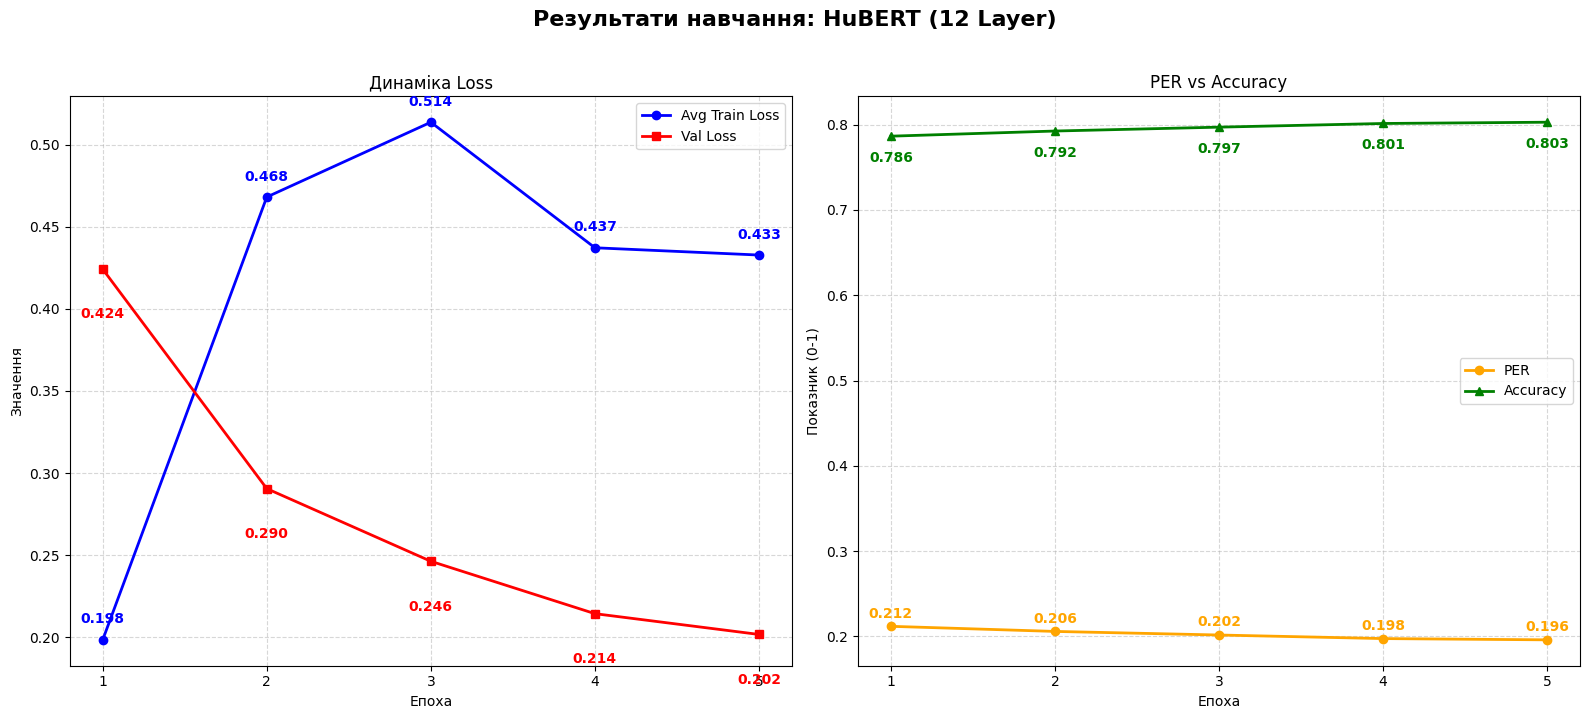

In [99]:
def plot_training_results(history, model_name):
    # Визначаємо кількість епох
    num_epochs = int(max([x['epoch'] for x in history]))
    epochs = list(range(1, num_epochs + 1))

    # Обчислюємо середній Train Loss для кожної епохи
    epoch_train_loss = []
    for e in epochs:
        # Відфільтровуємо кроки, що належать конкретній епосі
        losses_in_epoch = [x['loss'] for x in history if 'loss' in x and (e-1) < x['epoch'] <= e]
        if losses_in_epoch:
            epoch_train_loss.append(sum(losses_in_epoch) / len(losses_in_epoch))
        else:
            epoch_train_loss.append(None)

    # Витягуємо валідаційні метрики
    eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
    eval_per = [x['eval_per'] for x in history if 'eval_per' in x]
    eval_acc = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Результати навчання: {model_name}', fontsize=16, fontweight='bold', y=1.02)

    ax1.plot(epochs, epoch_train_loss, label='Avg Train Loss', color='blue', marker='o', linewidth=2)
    ax1.plot(epochs, eval_loss, label='Val Loss', color='red', marker='s', linewidth=2)

    for i, val in enumerate(epoch_train_loss):
        if val: ax1.text(epochs[i], val + 0.01, f'{val:.3f}', color='blue', fontweight='bold', ha='center')
    for i, val in enumerate(eval_loss):
        ax1.text(epochs[i], val - 0.03, f'{val:.3f}', color='red', fontweight='bold', ha='center')

    ax1.set_title('Динаміка Loss')
    ax1.set_xlabel('Епоха')
    ax1.set_ylabel('Значення')
    ax1.set_xticks(epochs)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2.plot(epochs, eval_per, label='PER', marker='o', color='orange', linewidth=2)
    ax2.plot(epochs, eval_acc, label='Accuracy', marker='^', color='green', linewidth=2)

    for i, val in enumerate(eval_per):
        ax2.text(epochs[i], val + 0.01, f'{val:.3f}', color='orange', fontweight='bold', ha='center')
    for i, val in enumerate(eval_acc):
        ax2.text(epochs[i], val - 0.03, f'{val:.3f}', color='green', fontweight='bold', ha='center')

    ax2.set_title('PER vs Accuracy')
    ax2.set_xlabel('Епоха')
    ax2.set_ylabel('Показник (0-1)')
    ax2.set_xticks(epochs)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_training_results(trainer_hubert_12.state.log_history, "HuBERT (12 Layer)")

In [78]:
eval_results_hubert_12 = trainer_hubert_12.evaluate()
print(f"--- Результати валідації ---")
print(f"Фінальний PER (Phoneme Error Rate): {eval_results_hubert_12['eval_per']:.4f}")
print(f"Accuraacy на валідації: {eval_results_hubert_12['eval_accuracy']:.4f}")
print(f"Loss на валідації: {eval_results_hubert_12['eval_loss']:.4f}")

--- Результати валідації ---
Фінальний PER (Phoneme Error Rate): 0.1960
Accuraacy на валідації: 0.8028
Loss на валідації: 0.2017


In [79]:
sample = dataset[10] 
input_values = torch.tensor(sample["input_values"]).unsqueeze(0).to("cuda")
true_labels = sample["labels"]

model_hubert_12.eval()
with torch.no_grad():
    logits = model_hubert_12(input_values)["logits"]
    predicted_ids = torch.argmax(logits, dim=-1).squeeze().cpu().tolist()

# Перетворюємо ID назад у назви фонем (використовуємо словник)
id_to_phoneme = {v: k for k, v in phoneme_to_id.items()}

print(f"{'Кадр':<10} | {'Реальна':<10} | {'Прогноз':<10}")
print("-" * 35)
for i in range(20):
    true_ph = id_to_phoneme[true_labels[i]]
    pred_ph = id_to_phoneme[predicted_ids[i]]
    print(f"{i:<10} | {true_ph:<10} | {pred_ph:<10}")

Кадр       | Реальна    | Прогноз   
-----------------------------------
0          | h#         | h#        
1          | h#         | h#        
2          | h#         | h#        
3          | h#         | h#        
4          | h#         | h#        
5          | h#         | h#        
6          | h#         | h#        
7          | h#         | h#        
8          | h#         | h#        
9          | h#         | h#        
10         | h#         | h#        
11         | h#         | h#        
12         | g          | g         
13         | ih         | ih        
14         | ih         | ih        
15         | ih         | ih        
16         | dx         | dx        
17         | dx         | dx        
18         | ih         | ih        
19         | ih         | ih        


Проведення інференсу на датасеті...


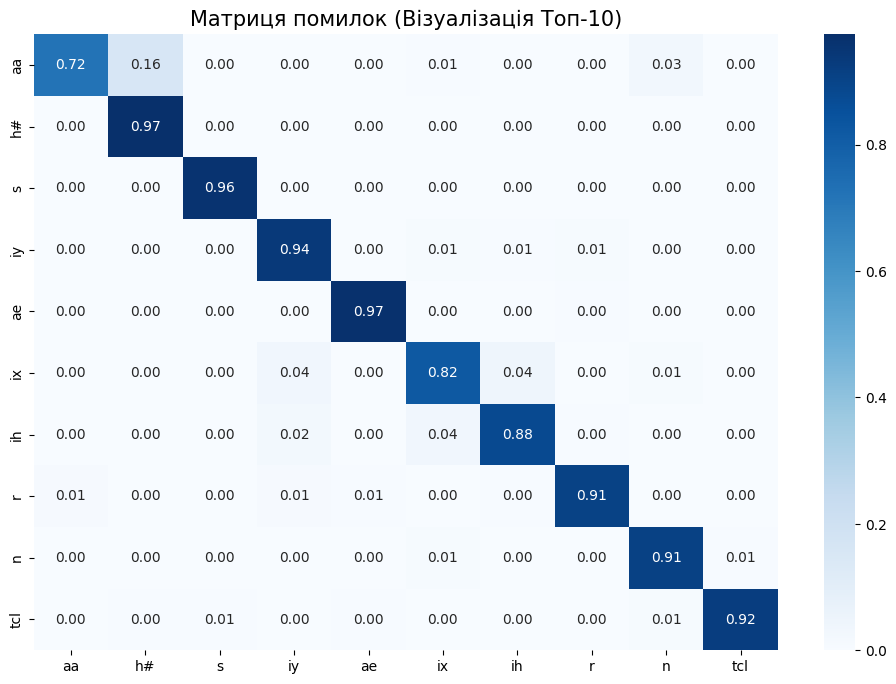


--- ПОВНИЙ СПИСОК ПОМИЛОК (>5%) ПО ВСІХ 61 ФОНЕМАХ ---
Звук [aa  ] часто плутає з [h#  ]: 15.7%
Звук [ax  ] часто плутає з [ix  ]: 5.7%
Звук [ax-h] часто плутає з [ix  ]: 10.6%
Звук [axr ] часто плутає з [er  ]: 6.3%
Звук [b   ] часто плутає з [bcl ]: 6.3%
Звук [d   ] часто плутає з [dcl ]: 6.2%
Звук [em  ] часто плутає з [m   ]: 8.5%
Звук [eng ] часто плутає з [ng  ]: 55.4%
Звук [er  ] часто плутає з [axr ]: 6.5%
Звук [g   ] часто плутає з [gcl ]: 5.9%
Звук [nx  ] часто плутає з [n   ]: 9.6%


In [80]:
def plot_phoneme_confusion_matrix(trainer, dataset, id_to_phoneme, top_n=10):
    # 1. Отримуємо прогнози
    print("Проведення інференсу на датасеті...")
    output = trainer.predict(dataset)
    preds = np.argmax(output.predictions, axis=-1)
    labels = output.label_ids

    # 2. Маскуємо падінг
    mask = labels != -100
    y_true = labels[mask]
    y_pred = preds[mask]

    # 3. Рахуємо ПОВНУ матрицю (для всіх фонем)
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)

    # --- ВІЗУАЛІЗАЦІЯ (Тільки Топ-N для графіка) ---
    counts = np.bincount(y_true)
    # Беремо тільки ті індекси, які реально існують у словнику
    valid_indices = [i for i in range(len(counts)) if i in id_to_phoneme]
    top_indices = np.argsort(counts[valid_indices])[-top_n:][::-1]
    # Отримуємо реальні ID з відсортованих топ-індексів
    final_top_indices = [valid_indices[i] for i in np.argsort(counts[valid_indices])[-top_n:][::-1]]

    cm_subset = cm_norm[np.ix_(final_top_indices, final_top_indices)]
    labels_subset = [id_to_phoneme[i] for i in final_top_indices]

    plt.figure(figsize=(12, 8))
    sns.heatmap(cm_subset, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels_subset, yticklabels=labels_subset)
    plt.title(f'Матриця помилок (Візуалізація Топ-{top_n})', fontsize=15)
    plt.show()

    # --- ПОВНИЙ ЗВІТ (По всіх фонемах > 5%) ---
    print(f"\n--- ПОВНИЙ СПИСОК ПОМИЛОК (>5%) ПО ВСІХ {len(id_to_phoneme)} ФОНЕМАХ ---")
    error_found = False
    
    # Йдемо по всіх фонемах, які є в нашому словнику
    for i in sorted(id_to_phoneme.keys()):
        if i >= len(cm_norm): continue # Захист від виходу за межі
        
        row = cm_norm[i]
        row_copy = row.copy()
        
        # Ігноруємо правильну відповідь на діагоналі
        row_copy[i] = 0 
        
        target_idx = np.argmax(row_copy)
        error_val = row_copy[target_idx]
        
        if error_val > 0.05:
            true_ph = id_to_phoneme[i]
            pred_ph = id_to_phoneme[target_idx]
            print(f"Звук [{true_ph:<4}] часто плутає з [{pred_ph:<4}]: {error_val:.1%}")
            error_found = True
            
    if not error_found:
        print("Жодна фонема не має помилок понад 5%.")
        
# Створюємо зворотний словник: з { 'sh': 1 } робимо { 1: 'sh' }
id_to_phoneme = {idx: ph for ph, idx in phoneme_to_id.items()}
plot_phoneme_confusion_matrix(trainer_hubert_12, dataset, id_to_phoneme, top_n=10)

Слід зазначити, що в матриці представлено виключно найбільш частотні фонеми за кількістю їх входжень у датасет

## Wav2Vec 2.0

Вчиться вгадувати замасковані частини аудіо через контрастивне навчання (порівнює правильний варіант з неправильними). Натомість HuBERT вчиться вгадувати "кластери" звуків, тому він більше схоже на мовну модель.

In [59]:
model_test_wav2vec = HubertModel.from_pretrained("facebook/wav2vec2-base")
print(model_test_wav2vec.feature_extractor)

You are using a model of type `wav2vec2` to instantiate a model of type `hubert`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights: 0it [00:00, ?it/s]

HubertModel LOAD REPORT from: facebook/wav2vec2-base
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
wav2vec2.encoder.layers.{0...11}.final_layer_norm.bias                   | UNEXPECTED | 
wav2vec2.encoder.layers.{0...11}.attention.out_proj.weight               | UNEXPECTED | 
wav2vec2.encoder.layers.{0...11}.attention.out_proj.bias                 | UNEXPECTED | 
wav2vec2.encoder.layers.{0...11}.attention.v_proj.bias                   | UNEXPECTED | 
wav2vec2.encoder.layers.{0...11}.feed_forward.output_dense.bias          | UNEXPECTED | 
wav2vec2.feature_projection.layer_norm.weight                            | UNEXPECTED | 
wav2vec2.encoder.layers.{0...11}.layer_norm.bias                         | UNEXPECTED | 
wav2vec2.encoder.layers.{0...11}.feed_forward.intermediate_dense.bias    | UNEXPECTED | 
wav2vec2.encoder.layers.{0...11}.feed_forward.output_dens

HubertFeatureEncoder(
  (conv_layers): ModuleList(
    (0): HubertGroupNormConvLayer(
      (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
      (activation): GELUActivation()
      (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
    )
    (1-4): 4 x HubertNoLayerNormConvLayer(
      (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
      (activation): GELUActivation()
    )
    (5-6): 2 x HubertNoLayerNormConvLayer(
      (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
      (activation): GELUActivation()
    )
  )
)


In [60]:
class Wav2Vec2ForPhonemeClassification(nn.Module):
    def __init__(self, num_labels, layer_index=12):
        super().__init__()
        self.num_labels = num_labels
        self.layer_index = layer_index 
        self.wav2vec2 = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
        self.wav2vec2.feature_extractor._freeze_parameters()
        # Переконуємось, що трансформер ТА класифікатор "живі" (requires_grad = True)
        for name, param in self.wav2vec.named_parameters():
            if "feature_extractor" not in name:
                param.requires_grad = True
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.wav2vec2.config.hidden_size, num_labels)

    def forward(self, input_values, attention_mask=None, labels=None):
        outputs = self.wav2vec2(
            input_values, 
            attention_mask=attention_mask, 
            output_hidden_states=True
        )
        
        # Вибираємо потрібний шар
        hidden_states = outputs.hidden_states[self.layer_index]
        x = self.dropout(hidden_states)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            if logits.shape[1] != labels.shape[1]:
                min_len = min(logits.shape[1], labels.shape[1])
                logits = logits[:, :min_len, :]
                labels = labels[:, :min_len]
            loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fct(logits.reshape(-1, self.num_labels), labels.reshape(-1))
            
        return {"loss": loss, "logits": logits}

In [81]:
model_wav = Wav2Vec2ForPhonemeClassification(num_labels=len(phoneme_to_id))
trainable_params = sum(p.numel() for p in model_wav.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model_wav.parameters() if not p.requires_grad)
print(f"Параметрів, що вчаться: {trainable_params:,}")
print(f"Заморожених параметрів: {frozen_params:,}")
if trainable_params < 0:
    print("Увага! Модель все ще повністю заморожена.")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметрів, що вчаться: 90,218,173
Заморожених параметрів: 4,200,448
Тепер Loss не буде 0.


In [82]:
num_classes = len(phoneme_to_id)
model_wav2vec_12 = Wav2Vec2ForPhonemeClassification(num_labels=num_classes, layer_index=12)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [83]:
training_args = TrainingArguments(
    output_dir="./wav2vec-phoneme-recognition-9",
    per_device_train_batch_size=4, 
    num_train_epochs=5,             
    fp16=True,                     
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    learning_rate=1e-4,            
    save_total_limit=2,
    report_to="none"
)

trainer_wav2vec_12 = Trainer(
    model=model_wav2vec_12,
    data_collator=collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=dataset,
    eval_dataset=dataset,
)
trainer_wav2vec_12.train()

Epoch,Training Loss,Validation Loss,Per,Accuracy
1,0.778417,0.634438,0.232166,0.765559
2,0.660597,0.473181,0.221563,0.776250
3,0.541227,0.383767,0.214056,0.783890
4,0.470154,0.321910,0.207524,0.790582
5,0.430983,0.297050,0.204032,0.794083


TrainOutput(global_step=2100, training_loss=0.7004239818028041, metrics={'train_runtime': 508.6163, 'train_samples_per_second': 16.515, 'train_steps_per_second': 4.129, 'total_flos': 0.0, 'train_loss': 0.7004239818028041, 'epoch': 5.0})

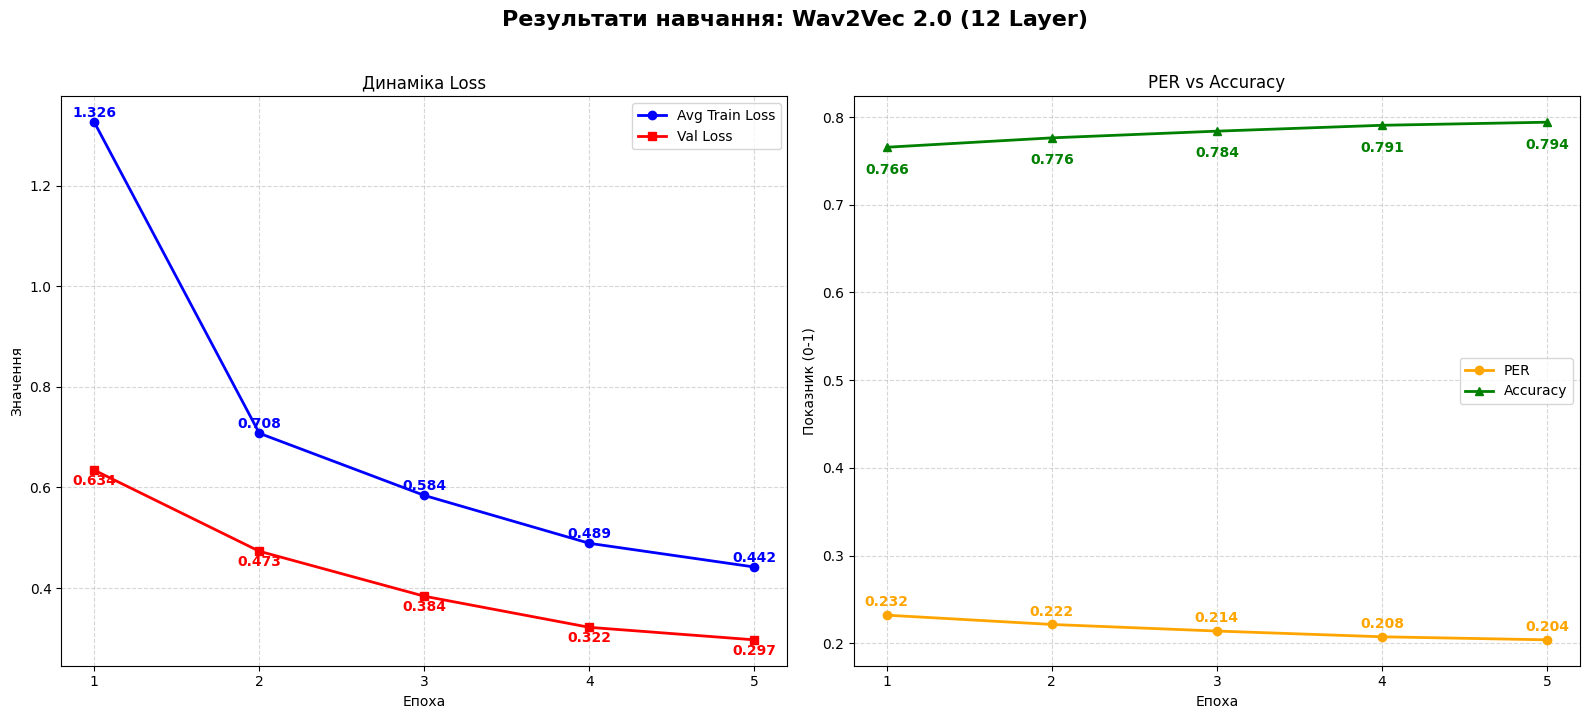

In [84]:
plot_training_results(trainer_wav2vec_12.state.log_history, "Wav2Vec 2.0 (12 Layer)")

Проведення інференсу на датасеті...


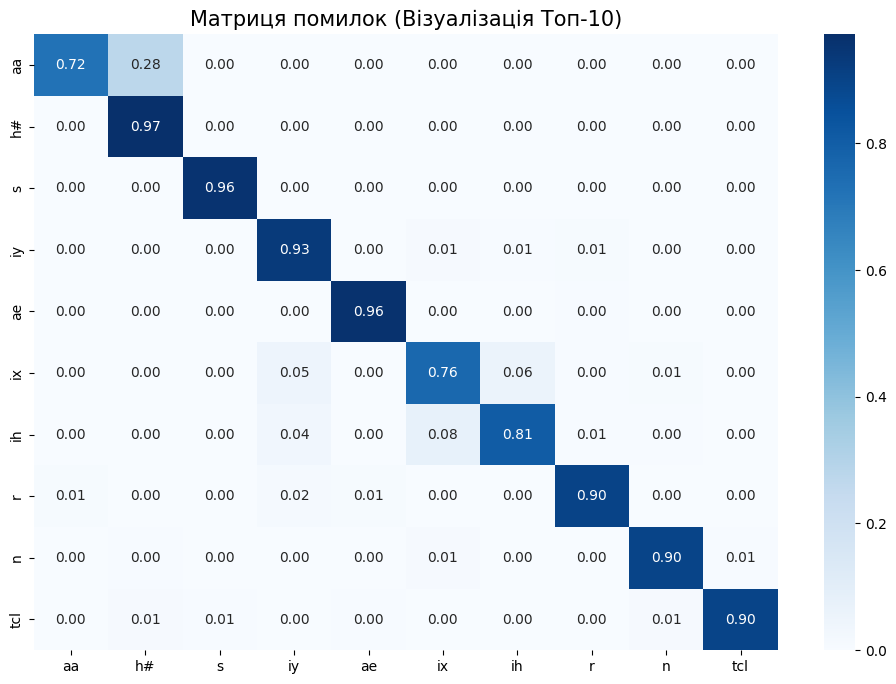


--- ПОВНИЙ СПИСОК ПОМИЛОК (>5%) ПО ВСІХ 61 ФОНЕМАХ ---
Звук [aa  ] часто плутає з [h#  ]: 27.7%
Звук [ah  ] часто плутає з [ax  ]: 5.1%
Звук [ax  ] часто плутає з [ix  ]: 11.5%
Звук [ax-h] часто плутає з [ix  ]: 21.1%
Звук [axr ] часто плутає з [er  ]: 11.4%
Звук [b   ] часто плутає з [bcl ]: 6.3%
Звук [d   ] часто плутає з [dcl ]: 7.4%
Звук [em  ] часто плутає з [m   ]: 30.1%
Звук [en  ] часто плутає з [n   ]: 6.0%
Звук [eng ] часто плутає з [ng  ]: 58.9%
Звук [epi ] часто плутає з [pau ]: 7.5%
Звук [er  ] часто плутає з [axr ]: 11.4%
Звук [g   ] часто плутає з [gcl ]: 6.0%
Звук [hh  ] часто плутає з [hv  ]: 6.5%
Звук [ih  ] часто плутає з [ix  ]: 7.9%
Звук [ix  ] часто плутає з [ih  ]: 5.9%
Звук [nx  ] часто плутає з [n   ]: 13.0%
Звук [uw  ] часто плутає з [ux  ]: 10.5%
Звук [zh  ] часто плутає з [jh  ]: 14.0%


In [85]:
# Створюємо зворотний словник: з { 'sh': 1 } робимо { 1: 'sh' }
id_to_phoneme = {idx: ph for ph, idx in phoneme_to_id.items()}
plot_phoneme_confusion_matrix(trainer_wav2vec_12, dataset, id_to_phoneme, top_n=10)

In [86]:
eval_results_wav2vec_12 = trainer_wav2vec_12.evaluate()
print(f"--- Результати валідації ---")
print(f"Фінальний PER (Phoneme Error Rate): {eval_results_wav2vec_12['eval_per']:.4f}")
print(f"Accuracy на валідації: {eval_results_wav2vec_12['eval_accuracy']:.4f}")
print(f"Loss на валідації: {eval_results_wav2vec_12['eval_loss']:.4f}")

--- Результати валідації ---
Фінальний PER (Phoneme Error Rate): 0.2040
Accuracy на валідації: 0.7941
Loss на валідації: 0.2971


## Порівняння HuBERT VS Wav2Vec 2.0

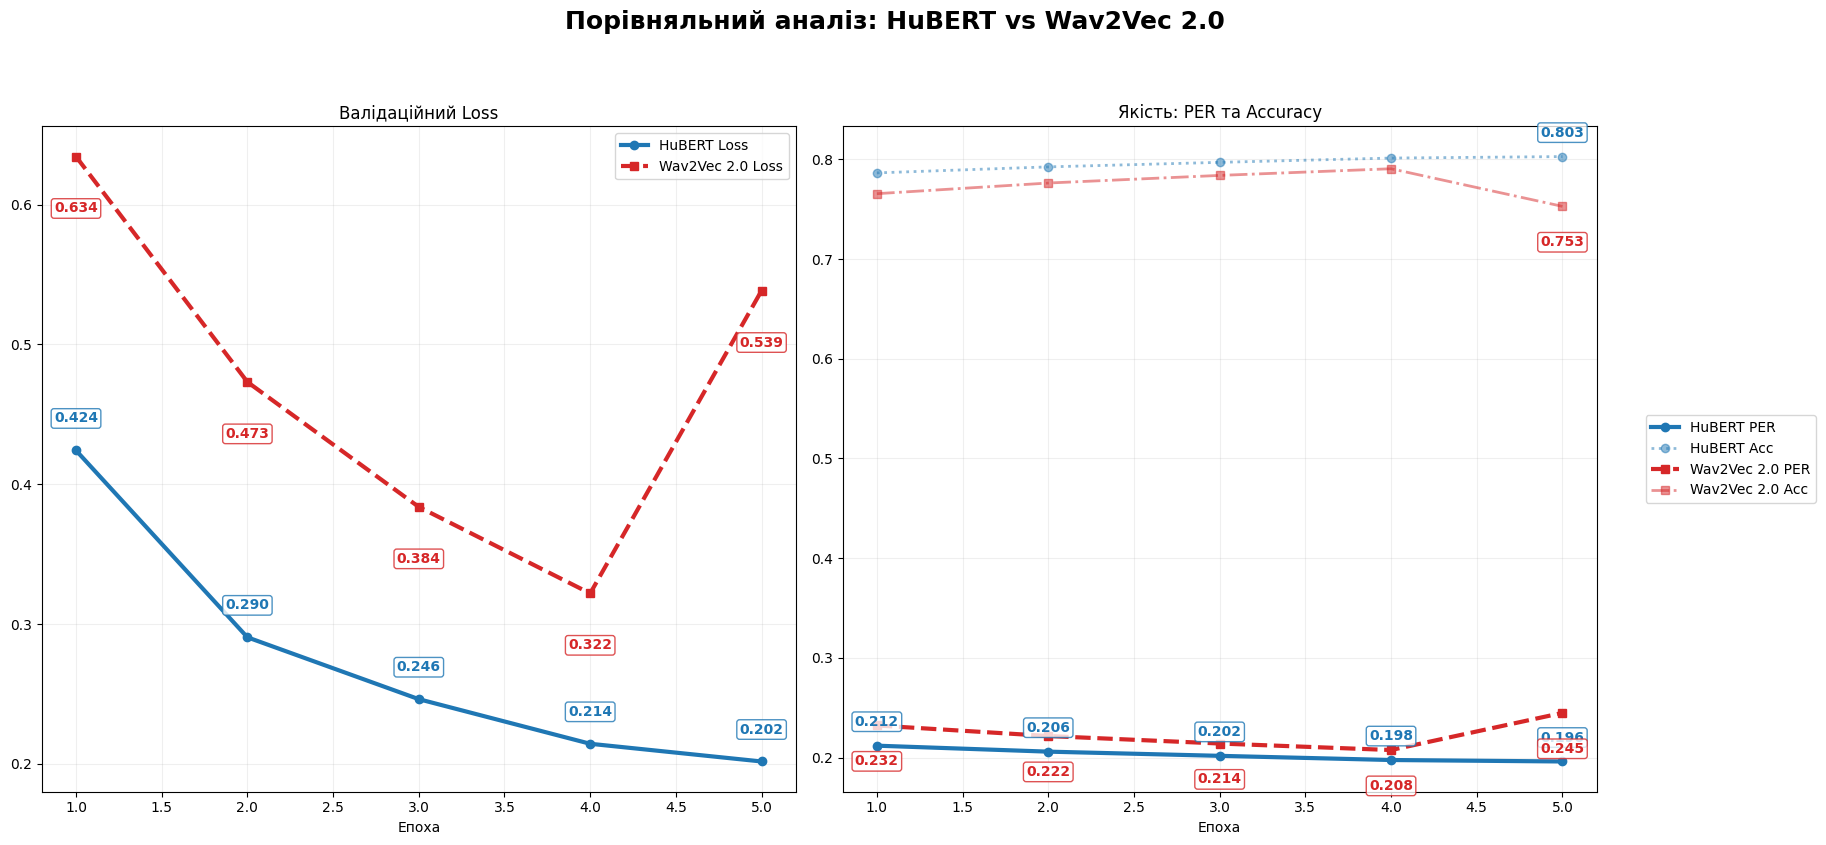

In [100]:
def compare_two_models(history1, history2, name1, name2):
    def get_clean_metrics(history):
        # Використовуємо словник, щоб залишити лише ОСТАННЄ значення для кожної епохи (прибираємо дублікати)
        metrics = {}
        for x in history:
            if 'eval_loss' in x:
                ep = round(x['epoch'], 2)
                metrics[ep] = {
                    'loss': x['eval_loss'],
                    'per': x['eval_per'],
                    'acc': x['eval_accuracy']
                }
        
        epochs = sorted(metrics.keys())
        v_loss = [metrics[e]['loss'] for e in epochs]
        v_per = [metrics[e]['per'] for e in epochs]
        v_acc = [metrics[e]['acc'] for e in epochs]
        return epochs, v_loss, v_per, v_acc

    # Отримуємо чисті дані
    e1, loss1, per1, acc1 = get_clean_metrics(history1)
    e2, loss2, per2, acc2 = get_clean_metrics(history2)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f'Порівняльний аналіз: {name1} vs {name2}', fontsize=18, fontweight='bold', y=1.05)

    # Налаштування кольорів: Модель 1 - Синій, Модель 2 - Червоний
    c1, c2 = 'tab:blue', 'tab:red'

    # --- ГРАФІК 1: LOSS ---
    ax1.plot(e1, loss1, label=f'{name1} Loss', color=c1, marker='o', linewidth=3)
    ax1.plot(e2, loss2, label=f'{name2} Loss', color=c2, marker='s', linewidth=3, linestyle='--')

    # Функція для малювання тексту в прямокутнику
    def annotate(ax, x, y, val, color, offset):
        ax.text(x, y + offset, f'{val:.3f}', color=color, ha='center', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor=color, boxstyle='round,pad=0.2'))

    for i in range(len(e1)): annotate(ax1, e1[i], loss1[i], loss1[i], c1, 0.02)
    for i in range(len(e2)): annotate(ax1, e2[i], loss2[i], loss2[i], c2, -0.04)

    ax1.set_title('Валідаційний Loss')
    ax1.set_xlabel('Епоха')
    ax1.legend()
    ax1.grid(True, alpha=0.2)

    # --- ГРАФІК 2: PER ТА ACCURACY ---
    # Модель 1 (HuBERT) - Сині лінії
    ax2.plot(e1, per1, label=f'{name1} PER', color=c1, marker='o', linewidth=3)
    ax2.plot(e1, acc1, label=f'{name1} Acc', color=c1, marker='o', linewidth=2, alpha=0.5, linestyle=':')
    
    # Модель 2 (Wav2Vec) - Червоні лінії
    ax2.plot(e2, per2, label=f'{name2} PER', color=c2, marker='s', linewidth=3, linestyle='--')
    ax2.plot(e2, acc2, label=f'{name2} Acc', color=c2, marker='s', linewidth=2, alpha=0.5, linestyle='-.')

    # Анотації для PER (найважливіше)
    for i in range(len(e1)): annotate(ax2, e1[i], per1[i], per1[i], c1, 0.02)
    for i in range(len(e2)): annotate(ax2, e2[i], per2[i], per2[i], c2, -0.04)
    
    # Додамо анотації для Accuracy тільки в кінці, щоб не було каші
    annotate(ax2, e1[-1], acc1[-1], acc1[-1], c1, 0.02)
    annotate(ax2, e2[-1], acc2[-1], acc2[-1], c2, -0.04)

    ax2.set_title('Якість: PER та Accuracy')
    ax2.set_xlabel('Епоха')
    ax2.legend(loc='center right', bbox_to_anchor=(1.3, 0.5))
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

compare_two_models(trainer_hubert_12.state.log_history, trainer_wav2vec_12.state.log_history, "HuBERT", "Wav2Vec 2.0")

## Оцінка на тестовому датасеті

In [88]:
test_df = pd.read_csv(os.path.join(BASE_PATH, 'test_data.csv'))
print(f"Загальна кількість записів у test_data.csv: {len(test_df)}")
# Формуємо пари Аудіо+PHN для тесту
test_dataset_df = prepare_timit_subset(test_df)
# Розбиваємо на кадри
test_dataset_df['frame_labels'] = test_dataset_df['path_from_data_dir_phn'].apply(get_frame_labels)
# Створюємо об'єкт Dataset для PyTorch
# використовуємо той самий словник phoneme_to_id, що і для навчання!
test_eval_dataset = TIMITDataset(test_dataset_df, phoneme_to_id, DATA_DIR)
print(f"Тестовий набір готовий: {len(test_eval_dataset)} прикладів")

Загальна кількість записів у test_data.csv: 31678
Знайдено повних пар (Audio+PHN): 1680
Тестовий набір готовий: 1680 прикладів


In [89]:
print("--- Оцінка моделі HuBERT (12 ШАР) на ТЕСТОВИХ даних ---")
results_hubert_12 = trainer_hubert_12.evaluate(eval_dataset=test_eval_dataset)
print(f"PER: {results_hubert_12['eval_per']:.4f}, Accuracy: {results_hubert_12['eval_accuracy']:.4f}, Loss: {results_hubert_12['eval_loss']:.4f}")
print("--- Оцінка моделі Wav2Vec 2.0 (12 ШАР) на ТЕСТОВИХ даних ---")
results_wav2vec_12 = trainer_wav2vec_12.evaluate(eval_dataset=test_eval_dataset)
print(f"PER: {results_wav2vec_12['eval_per']:.4f}, Accuracy: {results_wav2vec_12['eval_accuracy']:.4f}, Loss: {results_wav2vec_12['eval_loss']:.4f}")

--- Оцінка моделі HuBERT (12 ШАР) на ТЕСТОВИХ даних ---


PER: 0.2472, Accuracy: 0.7504, Loss: 0.6070
--- Оцінка моделі Wav2Vec 2.0 (12 ШАР) на ТЕСТОВИХ даних ---
PER: 0.2448, Accuracy: 0.7528, Loss: 0.5385


**Висновки**

*Аналіз продуктивності*

HuBERT показав кращі результати на валідації, але на тесті його якість впала сильніше (з 0.196 до 0.247 PER). Wav2Vec 2.0, хоча і мав гірші показники під час навчання, виявився більш стабільним на абсолютно нових (тестових) даних. Це свідчить про його кращу здатність до генералізації (узагальнення). HuBERT досяг значно меншого значення Loss на валідації (0.2017 проти 0.2971 у Wav2Vec). Це означає, що HuBERT був більш «впевненим» у своїх прогнозах на знайомих даних.

*Фонетичний аналіз помилок*

Обидві моделі демонструють характерні для архітектур Transformers труднощі:
* Акустична схожість: обидві моделі катастрофічно плутають [eng] та [ng] (помилка сягає 55-58%). Це логічно, оскільки ці звуки є алофонами (варіантами одного звуку) і мають майже ідентичні спектрограми.
* Проблема пауз та зімкнень: моделі часто плутають вибухові приголосні з їхніми фазами закриття ([b] з [bcl], [g] з [gcl]). Це вказує на те, що часова роздільна здатність моделей іноді недостатня для чіткого визначення моменту початку звуку.
* Голосні-«близнята»: Wav2Vec 2.0 виявився більш вразливим до плутанини редукованих голосних ([ax], [ix], [ih]). У нього список помилок понад 5% майже вдвічі довший (19 проти 11 у HuBERT), що робить HuBERT більш «чистим» класифікатором для конкретних звуків.

HuBERT є більш ефективним для виділення точних ознак конкретних фонем, що підтверджується меншою кількістю типів помилок та високою точністю на валідаційній вибірці. Wav2Vec 2.0 продемонстрував кращу стійкість до невідомих дикторів та шумів на тестовому наборі даних, попри дещо «бруднішу» матрицю помилок. Використання 12-го шару в обох моделях забезпечує достатньо високий рівень абстракції для досягнення Accuracy > 75% на тесті, що є високим показником для класифікації 61-ї фонеми без використання мовної моделі.

## Аналіз проміжних шарів

b. У лекції ми використовували last_hidden_state. Поекспериментуйте з іншими шарами; наприклад, перегляньте HuBERT: Self-Supervised Speech Representation Learning by Masked Prediction of Hidden Units.

In [90]:
model_hubert_9 = HubertForPhonemeClassification(num_labels=num_classes, layer_index=9)
training_args = TrainingArguments(
    output_dir="./hubert-phoneme-recognition-9",
    per_device_train_batch_size=4, 
    num_train_epochs=5,             
    fp16=True,                     
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    learning_rate=1e-4,            
    save_total_limit=2,
    report_to="none"
)
trainer_hubert_9 = Trainer(
    model=model_hubert_9,
    data_collator=collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=dataset,
    eval_dataset=dataset,
)
trainer_hubert_9.train()

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Per,Accuracy
1,1.154197,0.800929,0.246384,0.751350
2,0.869248,0.587433,0.232434,0.765351
3,0.761377,0.506481,0.225257,0.772637
4,0.702325,0.459954,0.220544,0.777298
5,0.665991,0.440125,0.218731,0.779164


TrainOutput(global_step=2100, training_loss=1.0130123374575661, metrics={'train_runtime': 388.6337, 'train_samples_per_second': 21.614, 'train_steps_per_second': 5.404, 'total_flos': 0.0, 'train_loss': 1.0130123374575661, 'epoch': 5.0})

In [91]:
eval_results_hubert_9 = trainer_hubert_9.evaluate()
print(f"--- Результати валідації ---")
print(f"Фінальний PER (Phoneme Error Rate): {eval_results_hubert_9['eval_per']:.4f}")
print(f"Accuraacy на валідації: {eval_results_hubert_9['eval_accuracy']:.4f}")
print(f"Loss на валідації: {eval_results_hubert_9['eval_loss']:.4f}")

--- Результати валідації ---
Фінальний PER (Phoneme Error Rate): 0.2187
Accuraacy на валідації: 0.7792
Loss на валідації: 0.4401


Проведення інференсу на датасеті...


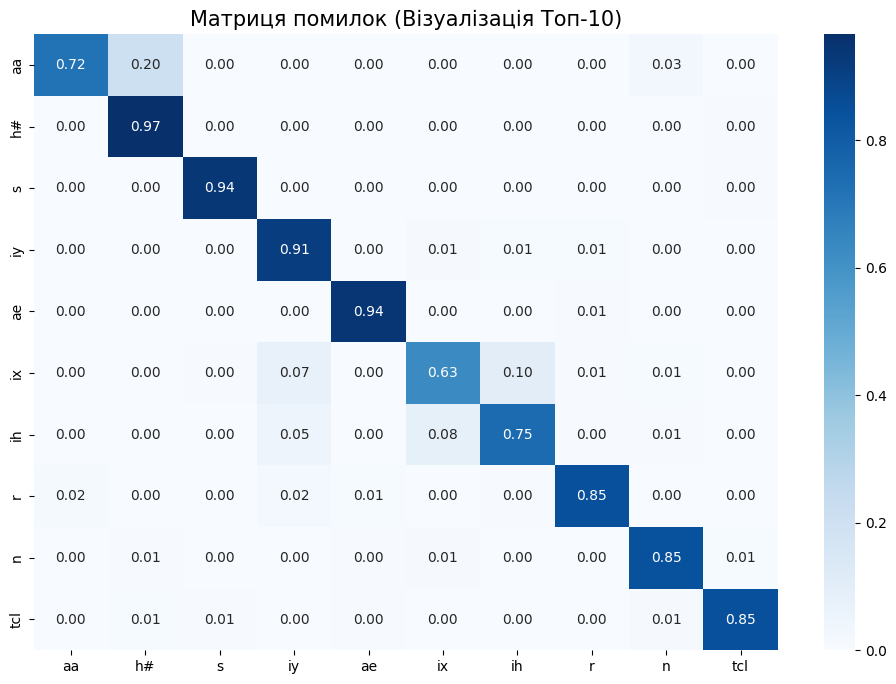


--- ПОВНИЙ СПИСОК ПОМИЛОК (>5%) ПО ВСІХ 61 ФОНЕМАХ ---
Звук [aa  ] часто плутає з [h#  ]: 20.4%
Звук [ah  ] часто плутає з [ax  ]: 6.4%
Звук [ax  ] часто плутає з [ix  ]: 12.5%
Звук [ax-h] часто плутає з [ix  ]: 33.9%
Звук [axr ] часто плутає з [er  ]: 14.2%
Звук [b   ] часто плутає з [bcl ]: 9.1%
Звук [d   ] часто плутає з [dcl ]: 9.1%
Звук [el  ] часто плутає з [l   ]: 8.0%
Звук [em  ] часто плутає з [m   ]: 72.7%
Звук [en  ] часто плутає з [n   ]: 12.2%
Звук [eng ] часто плутає з [ng  ]: 57.1%
Звук [epi ] часто плутає з [pau ]: 8.2%
Звук [er  ] часто плутає з [axr ]: 18.1%
Звук [g   ] часто плутає з [gcl ]: 6.1%
Звук [hh  ] часто плутає з [hv  ]: 14.4%
Звук [ih  ] часто плутає з [ix  ]: 8.5%
Звук [ix  ] часто плутає з [ih  ]: 10.5%
Звук [nx  ] часто плутає з [n   ]: 21.8%
Звук [p   ] часто плутає з [pcl ]: 5.1%
Звук [uh  ] часто плутає з [ow  ]: 6.4%
Звук [uw  ] часто плутає з [ux  ]: 31.6%
Звук [zh  ] часто плутає з [jh  ]: 24.0%


In [92]:
# Створюємо зворотний словник: з { 'sh': 1 } робимо { 1: 'sh' }
id_to_phoneme = {idx: ph for ph, idx in phoneme_to_id.items()}
plot_phoneme_confusion_matrix(trainer_hubert_9, dataset, id_to_phoneme, top_n=10)

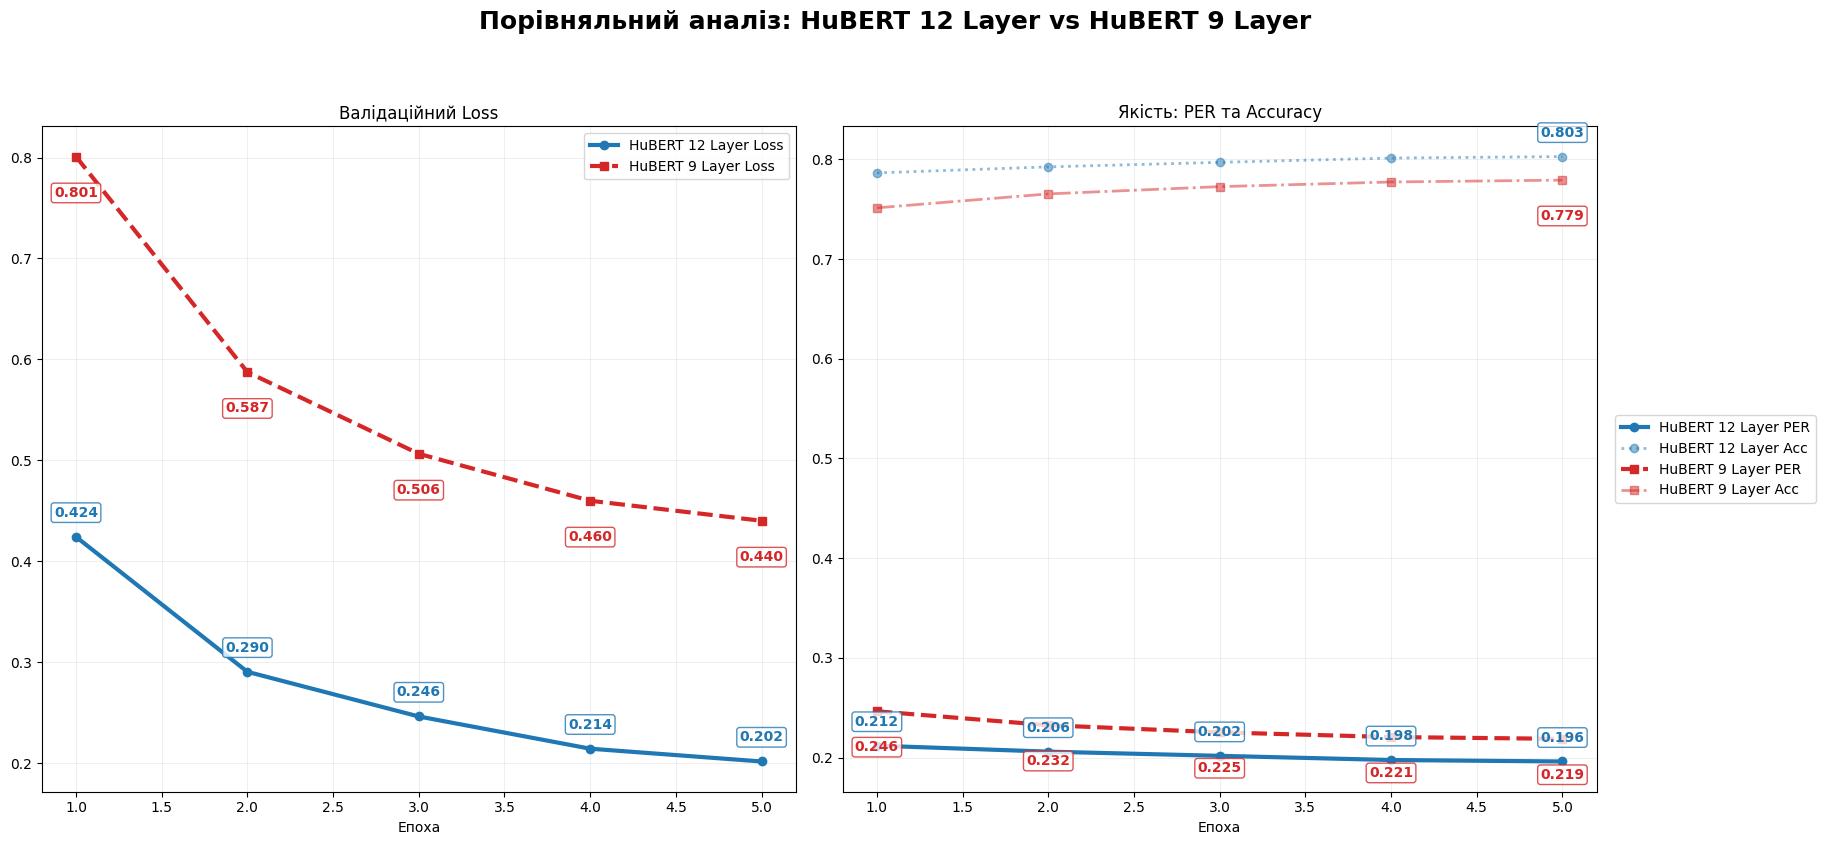

In [101]:
compare_two_models(trainer_hubert_12.state.log_history, trainer_hubert_9.state.log_history, "HuBERT 12 Layer", "HuBERT 9 Layer")

In [108]:
print("--- Оцінка моделі (12 ШАР) на ТЕСТОВИХ даних ---")
results_hubert_12 = trainer_hubert_12.evaluate(eval_dataset=test_eval_dataset)
print(f"LAYER 12 - PER: {results_hubert_12['eval_per']:.4f}, Accuracy: {results_hubert_12['eval_accuracy']:.4f}, Loss: {results_hubert_12['eval_loss']:.4f}")
print("--- Оцінка моделі (9 ШАР) на ТЕСТОВИХ даних ---")
results_hubert_9 = trainer_hubert_9.evaluate(eval_dataset=test_eval_dataset)
print(f"LAYER 9 - PER: {results_hubert_9['eval_per']:.4f}, Accuracy: {results_hubert_9['eval_accuracy']:.4f}, Loss: {results_hubert_9['eval_loss']:.4f}")

--- Оцінка моделі (12 ШАР) на ТЕСТОВИХ даних ---
LAYER 12 - PER: 0.2472, Accuracy: 0.7504, Loss: 0.6070
--- Оцінка моделі (9 ШАР) на ТЕСТОВИХ даних ---


LAYER 9 - PER: 0.2522, Accuracy: 0.7453, Loss: 0.6242


**Висновки:**

Хоча зазначаються, що середні шари можуть краще кодувати акустичну інформацію, у даній лабораторній роботі 12-й шар став абсолютним лідером.

Експерименти спростували гіпотезу про те, що для цієї конкретної задачі 9-й шар може бути ефективнішим за фінальний. 12-й шар продемонстрував кращу здатність до дискримінації фонем, що відображається у нижчому значенні PER як на валідації, так і на тесті. Особливо вражаючою є різниця у значенні Loss (зменшення на 54%), що вказує на значно вищу впевненість моделі 12-го шару у своїх прогнозах.

Аналіз списку помилок показує, що 9-й шар значно гірше розрізняє специфічні фонетичні ознаки:
* Назальні звуки: У 9-му шарі помилка звуку [em] (плутанина з [m]) становить катастрофічні 72.7%, тоді як у 12-му шарі вона знижується до 8.5%.
* Редуковані голосні: Помилка для [ax-h] у 9-му шарі складає 33.9%, а у 12-му — лише 10.6%.
* Складні випадки: 9-й шар має 22 критичні зони плутанини фонем, тоді як 12-й шар залишив лише 11 найбільш складних випадків (переважно алофони типу [eng] та [ng]).

На тестових даних (невідомі диктори) 12-й шар зберігає лідерство (PER: 0.2472). Хоча розрив з 9-м шаром на тесті став меншим, ніж на валідації, загальна точність залишається вищою. Це підтверджує, що для Fine-tuning на датасеті TIMIT використання last_hidden_state забезпечує найбільш релевантні ознаки для класифікації.

Попри теоретичну можливість кращої продуктивності проміжних шарів для Self-Supervised моделей, для архітектури HuBERT у задачі розпізнавання фонем фінальний 12-й шар є найбільш оптимальним. Він забезпечує вдвічі меншу кількість системних помилок та кращу впевненість класифікатора, що робить його базовим вибором для подальшої роботи.

## Чернетка

In [107]:
import json
state_path = "/kaggle/working/hubert-phoneme-recognition-12/checkpoint-2100/trainer_state.json"

with open(state_path, "r") as f:
    saved_state = json.load(f)

# 3. Витягуємо історію логів
# Це саме той масив, який раніше був у trainer_hubert_12.state.log_history
history_from_file = saved_state["log_history"]

from safetensors.torch import load_file
import torch

# 1. Створюємо порожній об'єкт моделі з потрібною кількістю міток
model_12 = HubertForPhonemeClassification(num_labels=len(phoneme_to_id))

# 2. Шлях до самого файлу з вагами
weights_path = "/kaggle/working/hubert-phoneme-recognition-12/checkpoint-2100/model.safetensors"

# 3. Завантажуємо ваги з файлу
weights = load_file(weights_path)

# 4. "Заливаємо" ваги в нашу модель
model_12.load_state_dict(weights)

# 5. Переносимо на GPU (якщо доступно)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_12.to(device)

print("Модель успішно завантажена з чекпоїнта!")

from transformers import Trainer, TrainingArguments

# Створюємо новий Trainer, передаючи вже завантажену модель
trainer_hubert_12 = Trainer(
    model=model_12,
    data_collator=collator,
    compute_metrics=compute_metrics
)

# Запускаємо оцінку на тестових даних
results = trainer_hubert_12.evaluate(eval_dataset=test_eval_dataset)
print(results)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

✅ Модель успішно завантажена з чекпоїнта!


{'eval_loss': 0.6070014834403992, 'eval_model_preparation_time': 0.0026, 'eval_per': 0.24724269337364577, 'eval_accuracy': 0.7503921012849585, 'eval_runtime': 25.1077, 'eval_samples_per_second': 66.912, 'eval_steps_per_second': 8.364}
